# Variational Quantum Eigensolver (VQE)

Running VQE Optimisation...


/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_25548/791349799.py:19: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_qubits, reps=1, entanglement='linear')


VQE Analysis: Ground State Estimation

Optimal Energy Found: -1.327575
Total Iterations: 100


1. Circuit Visualisation (Bound with Optimal Parameters)

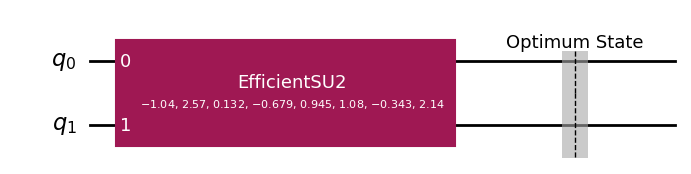

2. Unitary Evolution

The 4x4 unitary matrix of the optimised ansatz:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector of the ground state approximation:


<IPython.core.display.Latex object>


Final DensityMatrix:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


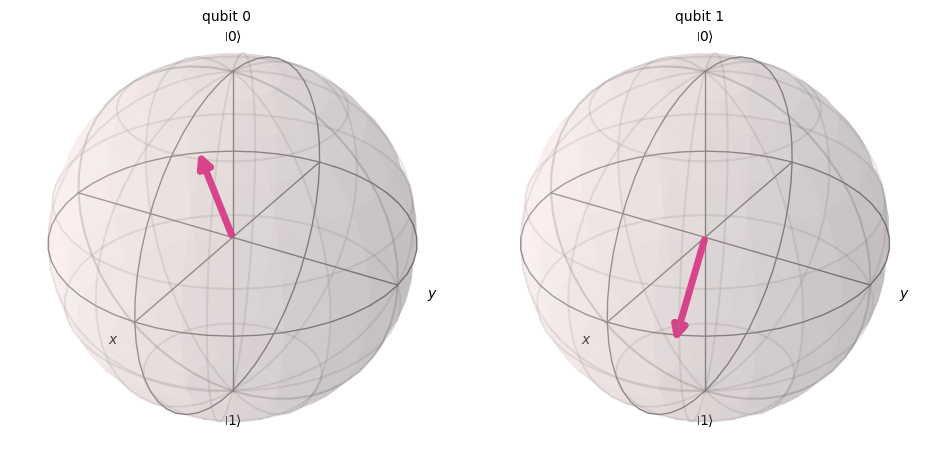


State prior to measurement (Q-Sphere):


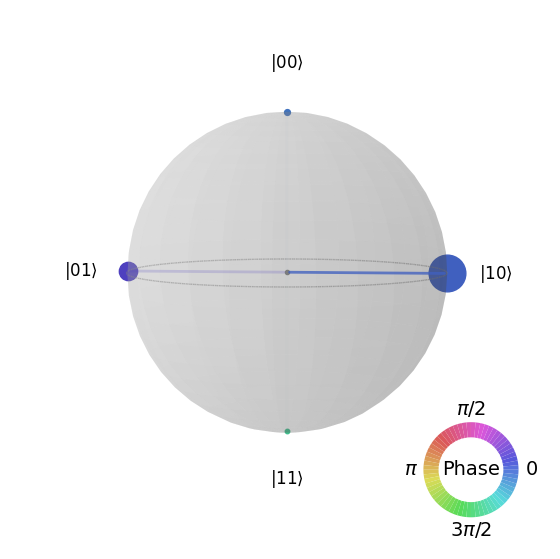

5. Measurement Analysis (Z-Basis)

Raw measurement counts: {'00': 21, '11': 11, '10': 781, '01': 211}


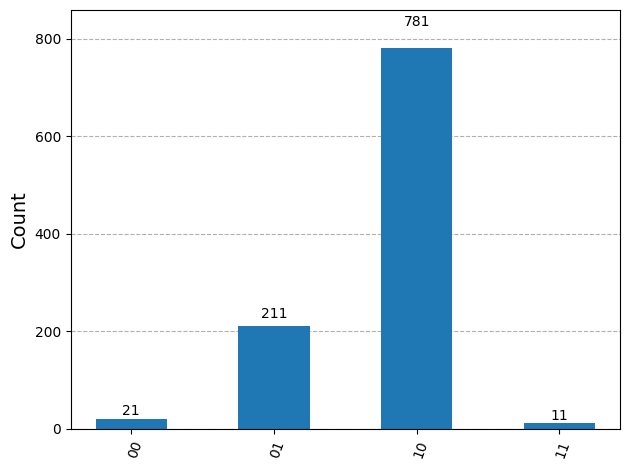

In [42]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, Operator
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION & PROBLEM DEFINITION
# ==========================================
# 1. Define the Hamiltonian (e.g., a simple molecule or spin model)
hamiltonian = SparsePauliOp.from_list([("ZZ", 1.0), ("XX", -0.5), ("IY", 0.2)])
num_qubits = hamiltonian.num_qubits

# 2. Define the Ansatz (Hardware-efficient heuristic)
ansatz = EfficientSU2(num_qubits=num_qubits, reps=1, entanglement='linear')

# ==========================================
# CLASSICAL OPTIMISATION LOOP
# ==========================================
estimator = StatevectorEstimator()
optimiser = COBYLA(maxiter=100)
energy_history = []

def cost_function(params):
    """Evaluates the expectation value <ψ(θ)|H|ψ(θ)>"""

    pub = (ansatz, hamiltonian, [params])
    job = estimator.run([pub])

    energy = job.result()[0].data.evs[0]

    energy_history.append(energy)
    return energy

# Random initialisation for parameters
np.random.seed(42) # Seeded for reproducible lab results
initial_theta = np.random.rand(ansatz.num_parameters)

# 3. Run Optimisation
print("Running VQE Optimisation...")
result = optimiser.minimize(fun=cost_function, x0=initial_theta)
optimal_energy = result.fun
optimal_params = result.x

# ==========================================
# EXTRACT EXACT MATH OF THE OPTIMAL STATE
# ==========================================
# Bind the classical optimiser's results to the quantum circuit
optimal_circuit = ansatz.assign_parameters(optimal_params)
optimal_circuit.barrier(label="Optimum State")

unitary = Operator(optimal_circuit)
final_state = Statevector(optimal_circuit)
final_density = DensityMatrix(optimal_circuit)

# Create a copy for Z-basis measurement
meas_circuit = optimal_circuit.copy()
meas_circuit.measure_all()

# Execute on AerSimulator for histogram
simulator = AerSimulator()
tqc = transpile(meas_circuit, simulator)
job = simulator.run(tqc, shots=1024)
counts = job.result().get_counts()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"VQE Analysis: Ground State Estimation"))
print(f"Optimal Energy Found: {optimal_energy:.6f}")
print(f"Total Iterations: {len(energy_history)}")

display(Markdown("1. Circuit Visualisation (Bound with Optimal Parameters)"))
display(optimal_circuit.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
if num_qubits <= 3:
    print(f"The {2**num_qubits}x{2**num_qubits} unitary matrix of the optimised ansatz:")
    display(array_to_latex(unitary.data, prefix="U_{VQE} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {num_qubits} qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector of the ground state approximation:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis (Z-Basis)"))
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))